# Centromere constraint analysis

1. **Phylogenetic persistence:** does CDR size track Y-chromosome ancestry (Pagel's λ)?
2. **Scaling:** does CDR size increase proportionally with total DYZ3 HOR size (PGLS of log CDR on log HOR)?
3. **Dispersion / boundedness:** is CDR size less dispersed than expected under the fitted size dynamics of the DYZ3 array?

## 1. Configuration and imports

In [1]:
from pathlib import Path
import copy
import itertools
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from Bio import Phylo
from scipy.optimize import minimize_scalar
from scipy.stats import t, linregress, spearmanr

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

TREE_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/"
    "Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex"
)

CENTROMERE_TABLE_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/LeeLab/HPRC/chromosomeY/"
    "Data/Centromere/SUPPL_TABLES_19Aug26_WORKING-VERSION - S22.csv"
)

OUTPUT_DIR = Path("centromere_constraint_v2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Simulation settings
N_SIM = 10_000
N_SIM_PHYSICAL = 2_000  
N_BOOT = 20_000
SEED_PRIMARY = 20260902
SEED_SENSITIVITY = 20260901
SEED_CDR_OWN = 20260903
SEED_BOOT = 20260904
SEED_PHYSICAL = 20260905

CDR_QUANTIZATION_KB = 5.0
CDR_DETECTION_FLOOR_KB = None
COVERAGE_COLUMN = None

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Output directory:", OUTPUT_DIR.resolve())

Python: 3.12.13
NumPy: 2.5.2
Pandas: 3.0.5
Output directory: /Users/markloftus/Desktop/UCONN/anaconda_projects/chrY/Pan-Y_Paper/Constraint/centromere_constraint_v2_outputs


## 2. Load and prepare centromere measurements

In [2]:
centromereCoordinateDF = pd.read_csv(CENTROMERE_TABLE_PATH)

centromere_model_df = centromereCoordinateDF.copy().rename(
    columns={
        "Coordinates of Active α-satellite HOR array": "HOR_coordinates",
        "Coordinates of CDR": "CDR_coordinates",
        "Y Haplogroup": "haplogroup",
        "Length of Active α-satellite HOR array (Mbp)": "HOR_Mb",
        "Length of CDR (kbp)": "CDR_kb",
    }
)

required = ["HOR_coordinates", "CDR_coordinates", "HOR_Mb", "CDR_kb"]
missing = [c for c in required if c not in centromere_model_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

centromere_model_df["sample"] = (
    centromere_model_df["HOR_coordinates"].astype(str).str.split("_chrY").str[0]
)
centromere_model_df["HOR_Mb"] = pd.to_numeric(centromere_model_df["HOR_Mb"], errors="coerce")
centromere_model_df["CDR_kb"] = pd.to_numeric(centromere_model_df["CDR_kb"], errors="coerce")
centromere_model_df["HOR_kb"] = 1000.0 * centromere_model_df["HOR_Mb"]
centromere_model_df["non_CDR_HOR_kb"] = centromere_model_df["HOR_kb"] - centromere_model_df["CDR_kb"]

centromere_model_df = centromere_model_df.dropna(
    subset=["sample", "HOR_kb", "CDR_kb", "non_CDR_HOR_kb"]
).copy()
centromere_model_df = centromere_model_df[
    (centromere_model_df["HOR_kb"] > 0)
    & (centromere_model_df["CDR_kb"] > 0)
    & (centromere_model_df["non_CDR_HOR_kb"] > 0)
].copy()

if not centromere_model_df["sample"].is_unique:
    dup = centromere_model_df.loc[
        centromere_model_df["sample"].duplicated(keep=False), "sample"
    ].tolist()
    raise ValueError(f"Duplicate sample names: {dup}")

centromere_model_df["CDR_within_HOR"] = centromere_model_df["CDR_kb"] < centromere_model_df["HOR_kb"]
if not centromere_model_df["CDR_within_HOR"].all():
    bad = centromere_model_df.loc[~centromere_model_df["CDR_within_HOR"], ["sample", "HOR_kb", "CDR_kb"]]
    raise ValueError(f"CDR >= HOR for one or more samples:\n{bad}")

# Log traits model proportional size differences.
centromere_model_df["log_CDR"] = np.log(centromere_model_df["CDR_kb"])
centromere_model_df["log_HOR"] = np.log(centromere_model_df["HOR_kb"])
centromere_model_df["log_non_CDR_HOR"] = np.log(centromere_model_df["non_CDR_HOR_kb"])
centromere_model_df["CDR_fraction"] = centromere_model_df["CDR_kb"] / centromere_model_df["HOR_kb"]

print("Complete centromeres:", len(centromere_model_df))
display(centromere_model_df[[
    "sample", "haplogroup", "HOR_kb", "CDR_kb", "non_CDR_HOR_kb", "CDR_fraction"
]].head())

Complete centromeres: 123


,sample,haplogroup,HOR_kb,CDR_kb,non_CDR_HOR_kb,CDR_fraction
0,HG01890,A,430.0,165,265.0,0.383721
1,HG02647,A,921.0,120,801.0,0.130293
2,HG02666,A,897.0,180,717.0,0.200669
3,HG02668,A,921.0,175,746.0,0.190011
4,HG03225,B,892.0,160,732.0,0.179372


## 3. Descriptive statistics and measurement-grid diagnostic

In [3]:
def trait_summary(name, values_kb):
    x = np.asarray(values_kb, float)
    lx = np.log(x)
    return {
        "Trait": name,
        "N": len(x),
        "Min_kb": x.min(),
        "Q1_kb": np.quantile(x, 0.25),
        "Median_kb": np.median(x),
        "Mean_kb": x.mean(),
        "Q3_kb": np.quantile(x, 0.75),
        "Max_kb": x.max(),
        "SD_kb": x.std(ddof=1),
        "Fold_range": x.max() / x.min(),
        "Log_SD": lx.std(ddof=1),
        "Log_variance": lx.var(ddof=1),
        "P05_P95_fold_range": np.exp(np.quantile(lx, 0.95) - np.quantile(lx, 0.05)),
    }

centromere_descriptive_table = pd.DataFrame([
    trait_summary("CDR", centromere_model_df["CDR_kb"]),
    trait_summary("Total DYZ3 HOR", centromere_model_df["HOR_kb"]),
    trait_summary("Non-CDR DYZ3 HOR", centromere_model_df["non_CDR_HOR_kb"]),
])

display(centromere_descriptive_table)
centromere_descriptive_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_Centromere_descriptive_statistics.csv", index=False
)

remainder = np.mod(centromere_model_df["CDR_kb"].to_numpy(float), CDR_QUANTIZATION_KB)
quantization_table = pd.DataFrame({
    "N": [len(remainder)],
    "Candidate_increment_kb": [CDR_QUANTIZATION_KB],
    "N_exact_multiples": [int(np.isclose(remainder, 0, atol=1e-8).sum())],
    "Fraction_exact_multiples": [float(np.isclose(remainder, 0, atol=1e-8).mean())],
    "Minimum_observed_CDR_kb": [centromere_model_df["CDR_kb"].min()],
})
display(quantization_table)
quantization_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_CDR_quantization_diagnostic.csv", index=False
)

,Trait,N,Min_kb,Q1_kb,Median_kb,Mean_kb,Q3_kb,Max_kb,SD_kb,Fold_range,Log_SD,Log_variance,P05_P95_fold_range
0,CDR,123,90.0,115.0,135.0,147.601626,170.0,285.0,42.812734,3.166667,0.271206,0.073553,2.368421
1,Total DYZ3 HOR,123,121.0,422.5,783.0,771.040650,1005.5,1673.0,374.829347,13.826446,0.546878,0.299076,4.973540
2,Non-CDR DYZ3 HOR,123,26.0,282.0,619.0,623.439024,858.5,1504.0,373.105842,57.846154,0.764953,0.585153,9.833439


,N,Candidate_increment_kb,N_exact_multiples,Fraction_exact_multiples,Minimum_observed_CDR_kb
0,123,5.0,123,1.0,90


## 4. Load and prune the Y phylogeny

In [4]:
tree = Phylo.read(TREE_PATH, "nexus")
tree_centromere = copy.deepcopy(tree)

centromere_samples = set(centromere_model_df["sample"])
tree_tip_names = {tip.name for tip in tree_centromere.get_terminals()}
missing_from_tree = sorted(centromere_samples - tree_tip_names)
if missing_from_tree:
    print("Centromere samples missing from tree:", missing_from_tree)

for tip in list(tree_centromere.get_terminals()):
    if tip.name not in centromere_samples:
        tree_centromere.prune(tip)

tip_names = [tip.name for tip in tree_centromere.get_terminals()]
centromere_traits = centromere_model_df.set_index("sample").loc[tip_names].copy()

print("Original tree tips:", len(tree.get_terminals()))
print("Pruned tree tips:", len(tree_centromere.get_terminals()))
print("Aligned trait rows:", len(centromere_traits))

Original tree tips: 142
Pruned tree tips: 123
Aligned trait rows: 123


## 5. Phylogenetic covariance and numerical diagnostics

In [5]:
def build_phylogenetic_matrices(tree, tip_names):
    tip_lookup = {tip.name: tip for tip in tree.get_terminals()}
    tips = [tip_lookup[name] for name in tip_names]
    depths = tree.depths()

    root_to_tip_original = np.array([depths[tip] for tip in tips], dtype=float)
    positive = root_to_tip_original[root_to_tip_original > 0]
    if len(positive) == 0:
        raise ValueError("Tree has no positive root-to-tip branch lengths.")
    branch_scale = float(np.median(positive))
    root_to_tip = root_to_tip_original / branch_scale

    n = len(tips)
    shared_original = np.zeros((n, n), dtype=float)
    for i, tip_i in enumerate(tips):
        for j in range(i, n):
            tip_j = tips[j]
            if i == j:
                d = root_to_tip_original[i]
            else:
                d = depths[tree.common_ancestor(tip_i, tip_j)]
            shared_original[i, j] = d
            shared_original[j, i] = d

    shared = shared_original / branch_scale
    return {
        "root_to_tip_original": root_to_tip_original,
        "root_to_tip": root_to_tip,
        "shared_original": shared_original,
        "shared": shared,
        "branch_scale": branch_scale,
    }

phylo_matrices = build_phylogenetic_matrices(tree_centromere, tip_names)
C_BM = phylo_matrices["shared"]

eigenvalues = np.linalg.eigvalsh(C_BM)
terminal_branch_lengths = np.array([
    tip.branch_length for tip in tree_centromere.get_terminals()
    if tip.branch_length is not None
], dtype=float)

tree_diagnostics = pd.DataFrame({
    "N_tips": [len(tip_names)],
    "Original_median_root_to_tip": [phylo_matrices["branch_scale"]],
    "Scaled_min_root_to_tip": [phylo_matrices["root_to_tip"].min()],
    "Scaled_max_root_to_tip": [phylo_matrices["root_to_tip"].max()],
    "Covariance_min_eigenvalue": [eigenvalues.min()],
    "Covariance_condition_number": [np.linalg.cond(C_BM)],
    "Min_terminal_branch_original_units": [terminal_branch_lengths.min()],
    "Median_terminal_branch_original_units": [np.median(terminal_branch_lengths)],
    "Max_terminal_branch_original_units": [terminal_branch_lengths.max()],
})
display(tree_diagnostics)
tree_diagnostics.to_csv(OUTPUT_DIR / "Supplementary_Table_Tree_diagnostics.csv", index=False)

,N_tips,Original_median_root_to_tip,Scaled_min_root_to_tip,Scaled_max_root_to_tip,Covariance_min_eigenvalue,Covariance_condition_number,Min_terminal_branch_original_units,Median_terminal_branch_original_units,Max_terminal_branch_original_units
0,123,0.184293,0.999989,1.000005,0.000147,544513.882487,0.000027,0.006966,0.184292


## 6. Core likelihood functions and Pagel's λ

In [6]:
def _stabilize_covariance(Q, relative_jitter=1e-10):
    Q = np.asarray(Q, float).copy()
    diag_mean = float(np.mean(np.diag(Q)))
    jitter = max(abs(diag_mean) * relative_jitter, 1e-12)
    return Q + np.eye(Q.shape[0]) * jitter


def fit_gls_covariance(y, base_covariance):
    # ML fit of y ~ N(mu, sigma^2 Q).
    y = np.asarray(y, float)
    Q = _stabilize_covariance(base_covariance)
    n = len(y)
    ones = np.ones(n)

    try:
        Qinv_y = np.linalg.solve(Q, y)
        Qinv_ones = np.linalg.solve(Q, ones)
    except np.linalg.LinAlgError:
        return None

    denom = float(ones @ Qinv_ones)
    if denom <= 0:
        return None
    mu = float((ones @ Qinv_y) / denom)
    resid = y - mu

    try:
        Qinv_resid = np.linalg.solve(Q, resid)
    except np.linalg.LinAlgError:
        return None

    rss = float(resid @ Qinv_resid)
    sigma2 = rss / n
    sign, logdet_Q = np.linalg.slogdet(Q)
    if sigma2 <= 0 or sign <= 0 or not np.isfinite(logdet_Q):
        return None

    logLik = -0.5 * (
        n * np.log(2 * np.pi)
        + n * np.log(sigma2)
        + logdet_Q
        + n
    )
    return {"mu": mu, "sigma2": float(sigma2), "logLik": float(logLik)}


def pagel_lambda_covariance(lambda_value, shared):
    Q = np.asarray(shared, float).copy()
    n = Q.shape[0]
    mask = ~np.eye(n, dtype=bool)
    Q[mask] *= float(lambda_value)
    return Q


def fit_pagel_lambda_model(y, phylo):
    y = np.asarray(y, float)
    shared = phylo["shared"]

    def fit_at(lam):
        fit = fit_gls_covariance(y, pagel_lambda_covariance(lam, shared))
        if fit is None:
            return None
        return {**fit, "lambda": float(lam)}

    def objective(lam):
        fit = fit_at(lam)
        return np.inf if fit is None else -fit["logLik"]

    opt = minimize_scalar(objective, bounds=(1e-8, 1 - 1e-8), method="bounded")
    candidates = [fit_at(0.0), fit_at(float(opt.x)), fit_at(1.0)]
    candidates = [x for x in candidates if x is not None]
    if not candidates:
        raise RuntimeError("Pagel lambda fit failed at all candidate values.")
    return max(candidates, key=lambda x: x["logLik"])


def profile_pagel_lambda(y, phylo, trait_name, grid_size=2001):
    grid = np.linspace(0.0, 1.0, grid_size)
    rows = []
    for lam in grid:
        fit = fit_gls_covariance(y, pagel_lambda_covariance(lam, phylo["shared"]))
        rows.append((lam, np.nan if fit is None else fit["logLik"]))
    prof = pd.DataFrame(rows, columns=["lambda", "logLik"])
    mle = fit_pagel_lambda_model(y, phylo)
    max_ll = mle["logLik"]

    cutoff = max_ll - 1.920729410347062
    supported = prof.loc[prof["logLik"] >= cutoff, "lambda"]
    lo = float(supported.min()) if len(supported) else np.nan
    hi = float(supported.max()) if len(supported) else np.nan

    f0 = fit_gls_covariance(y, pagel_lambda_covariance(0.0, phylo["shared"]))
    f1 = fit_gls_covariance(y, pagel_lambda_covariance(1.0, phylo["shared"]))
    summary = {
        "Trait": trait_name,
        "N": len(y),
        "Lambda_MLE": mle["lambda"],
        "Lambda_profile_support_low": lo,
        "Lambda_profile_support_high": hi,
        "Sigma2_ML": mle["sigma2"],
        "Mean_log_length": mle["mu"],
        "logLik_MLE": mle["logLik"],
        "logLik_lambda0": f0["logLik"],
        "logLik_lambda1_BM": f1["logLik"],
        "Delta_logLik_MLE_vs_lambda0": mle["logLik"] - f0["logLik"],
        "Delta_logLik_MLE_vs_lambda1": mle["logLik"] - f1["logLik"],
        "Boundary_MLE": bool(np.isclose(mle["lambda"], 0) or np.isclose(mle["lambda"], 1)),
    }
    prof["Trait"] = trait_name
    prof["Delta_logLik"] = prof["logLik"] - max_ll
    return summary, prof

## 7. Pagel-λ analysis and profile-likelihood figure

In [7]:
traits_for_lambda = {
    "CDR": centromere_traits["log_CDR"].to_numpy(),
    "Total DYZ3 HOR": centromere_traits["log_HOR"].to_numpy(),
    "Non-CDR DYZ3 HOR": centromere_traits["log_non_CDR_HOR"].to_numpy(),
}

lambda_summaries = []
lambda_profiles = []
for trait_name, y in traits_for_lambda.items():
    s, p = profile_pagel_lambda(y, phylo_matrices, trait_name)
    lambda_summaries.append(s)
    lambda_profiles.append(p)

pagel_lambda_table = pd.DataFrame(lambda_summaries)
pagel_lambda_profile_df = pd.concat(lambda_profiles, ignore_index=True)

display(pagel_lambda_table)
pagel_lambda_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_Pagel_lambda_centromere_traits.csv", index=False
)
pagel_lambda_profile_df.to_csv(
    OUTPUT_DIR / "Supplementary_Data_Pagel_lambda_profiles.csv", index=False
)

for trait_name, y in traits_for_lambda.items():
    fit_bm = fit_gls_covariance(y, phylo_matrices["shared"])
    fit_l1 = fit_gls_covariance(y, pagel_lambda_covariance(1.0, phylo_matrices["shared"]))
    print(
        trait_name,
        "BM vs lambda=1 logLik difference =",
        fit_l1["logLik"] - fit_bm["logLik"],
        "covariance identical =",
        np.allclose(phylo_matrices["shared"], pagel_lambda_covariance(1.0, phylo_matrices["shared"])),
    )

/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


,Trait,N,Lambda_MLE,Lambda_profile_support_low,Lambda_profile_support_high,Sigma2_ML,Mean_log_length,logLik_MLE,logLik_lambda0,logLik_lambda1_BM,Delta_logLik_MLE_vs_lambda0,Delta_logLik_MLE_vs_lambda1,Boundary_MLE
0,CDR,123,0.000000,0.000,0.115,0.072955,4.956629,-13.527708,-13.527708,-199.651120,0.000000,186.123412,True
1,Total DYZ3 HOR,123,1.000000,1.000,1.000,0.957588,6.370155,-11.389981,-99.793329,-11.389981,88.403349,0.000000,True
2,Non-CDR DYZ3 HOR,123,0.986169,0.965,0.994,1.850724,6.003716,-81.491396,-141.070650,-177.242694,59.579254,95.751298,False


CDR BM vs lambda=1 logLik difference = 0.0 covariance identical = True
Total DYZ3 HOR BM vs lambda=1 logLik difference = 0.0 covariance identical = True
Non-CDR DYZ3 HOR BM vs lambda=1 logLik difference = 0.0 covariance identical = True


/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


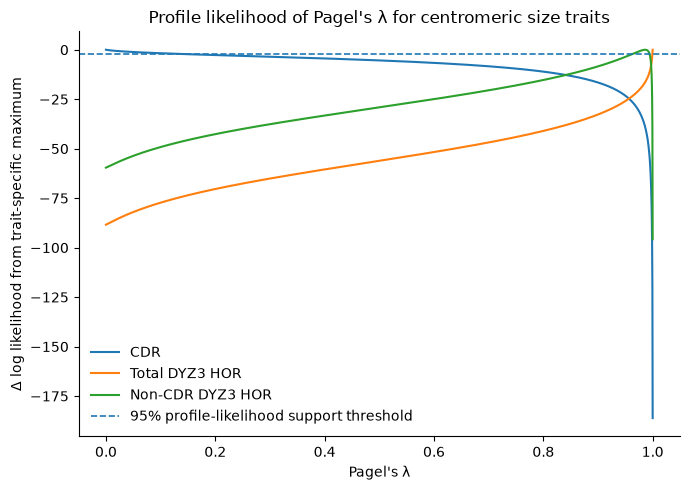

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for trait_name, tmp in pagel_lambda_profile_df.groupby("Trait", sort=False):
    ax.plot(tmp["lambda"], tmp["Delta_logLik"], label=trait_name)
ax.axhline(-1.920729410347062, linestyle="--", linewidth=1.2, label="95% profile-likelihood support threshold")
ax.set_xlabel("Pagel's λ")
ax.set_ylabel("Δ log likelihood from trait-specific maximum")
ax.set_title("Profile likelihood of Pagel's λ for centromeric size traits")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure_Pagel_lambda_profiles.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Figure_Pagel_lambda_profiles.png", dpi=600, bbox_inches="tight")
plt.show()

## 8. PGLS: does CDR size scale with total DYZ3 HOR size?

In [9]:
def fit_pgls_given_lambda(y, x, shared, lambda_value):
    y = np.asarray(y, float)
    x = np.asarray(x, float)
    n = len(y)
    X = np.column_stack([np.ones(n), x])
    p = X.shape[1]
    Q = _stabilize_covariance(pagel_lambda_covariance(lambda_value, shared))

    try:
        Qinv_X = np.linalg.solve(Q, X)
        Qinv_y = np.linalg.solve(Q, y)
        XtQX = X.T @ Qinv_X
        XtQX_inv = np.linalg.inv(XtQX)
    except np.linalg.LinAlgError:
        return None

    beta = XtQX_inv @ X.T @ Qinv_y
    resid = y - X @ beta
    try:
        Qinv_resid = np.linalg.solve(Q, resid)
    except np.linalg.LinAlgError:
        return None
    rss = float(resid @ Qinv_resid)
    sigma2_ml = rss / n
    sign, logdet_Q = np.linalg.slogdet(Q)
    if sigma2_ml <= 0 or sign <= 0:
        return None

    logLik = -0.5 * (
        n * np.log(2 * np.pi) + n * np.log(sigma2_ml) + logdet_Q + n
    )

    sigma2_se = rss / (n - p)
    beta_cov = sigma2_se * XtQX_inv
    beta_se = np.sqrt(np.diag(beta_cov))
    fitted = X @ beta

    return {
        "lambda": float(lambda_value),
        "beta": beta,
        "beta_se": beta_se,
        "sigma2": float(sigma2_ml),
        "logLik": float(logLik),
        "df": n - p,
        "fitted": fitted,
        "residuals": resid,
    }


def fit_pgls_lambda(y, x, shared):
    def objective(lam):
        fit = fit_pgls_given_lambda(y, x, shared, lam)
        return np.inf if fit is None else -fit["logLik"]

    opt = minimize_scalar(objective, bounds=(1e-8, 1 - 1e-8), method="bounded")
    candidates = [
        fit_pgls_given_lambda(y, x, shared, 0.0),
        fit_pgls_given_lambda(y, x, shared, float(opt.x)),
        fit_pgls_given_lambda(y, x, shared, 1.0),
    ]
    candidates = [z for z in candidates if z is not None]
    best = max(candidates, key=lambda z: z["logLik"])

    beta0, beta1 = best["beta"]
    _, se1 = best["beta_se"]
    df = best["df"]
    crit = t.ppf(0.975, df)

    t0 = beta1 / se1
    t1 = (beta1 - 1.0) / se1
    return {
        **best,
        "intercept": float(beta0),
        "slope": float(beta1),
        "slope_SE": float(se1),
        "slope_CI_low": float(beta1 - crit * se1),
        "slope_CI_high": float(beta1 + crit * se1),
        "P_slope_equals_0": float(2 * t.sf(abs(t0), df)),
        "P_slope_equals_1": float(2 * t.sf(abs(t1), df)),
    }

pgls_fit = fit_pgls_lambda(
    y=centromere_traits["log_CDR"].to_numpy(),
    x=centromere_traits["log_HOR"].to_numpy(),
    shared=phylo_matrices["shared"],
)

pgls_table = pd.DataFrame([{
    "N": len(centromere_traits),
    "Residual_Pagel_lambda": pgls_fit["lambda"],
    "Intercept": pgls_fit["intercept"],
    "Slope_logCDR_on_logHOR": pgls_fit["slope"],
    "Slope_SE": pgls_fit["slope_SE"],
    "Slope_95CI_low": pgls_fit["slope_CI_low"],
    "Slope_95CI_high": pgls_fit["slope_CI_high"],
    "P_slope_equals_0": pgls_fit["P_slope_equals_0"],
    "P_slope_equals_1_proportional_scaling": pgls_fit["P_slope_equals_1"],
    "logLik": pgls_fit["logLik"],
}])

display(pgls_table)
pgls_table.to_csv(OUTPUT_DIR / "Supplementary_Table_PGLS_CDR_vs_total_HOR.csv", index=False)

,N,Residual_Pagel_lambda,Intercept,Slope_logCDR_on_logHOR,Slope_SE,Slope_95CI_low,Slope_95CI_high,P_slope_equals_0,P_slope_equals_1_proportional_scaling,logLik
0,123,0.0,4.537831,0.064298,0.044703,-0.024203,0.152799,0.15292,4.960439e-42,-12.485092


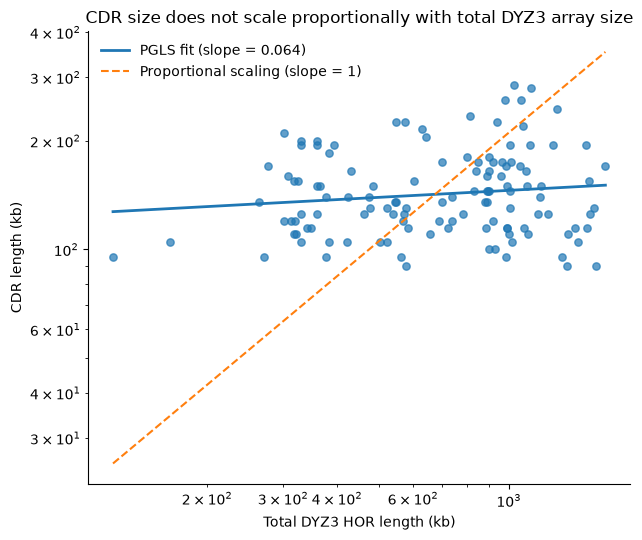

In [10]:
# PGLS visualization on logarithmic axes.
x_kb = centromere_traits["HOR_kb"].to_numpy(float)
y_kb = centromere_traits["CDR_kb"].to_numpy(float)
x_log = np.log(x_kb)

x_grid_log = np.linspace(x_log.min(), x_log.max(), 300)
y_fit_log = pgls_fit["intercept"] + pgls_fit["slope"] * x_grid_log

prop_intercept = np.mean(np.log(y_kb)) - np.mean(np.log(x_kb))
y_prop_log = prop_intercept + x_grid_log

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(x_kb, y_kb, s=28, alpha=0.7)
ax.plot(np.exp(x_grid_log), np.exp(y_fit_log), linewidth=2, label=f"PGLS fit (slope = {pgls_fit['slope']:.3f})")
ax.plot(np.exp(x_grid_log), np.exp(y_prop_log), linestyle="--", linewidth=1.5, label="Proportional scaling (slope = 1)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total DYZ3 HOR length (kb)")
ax.set_ylabel("CDR length (kb)")
ax.set_title("CDR size does not scale proportionally with total DYZ3 array size")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure_PGLS_CDR_vs_total_HOR.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Figure_PGLS_CDR_vs_total_HOR.png", dpi=600, bbox_inches="tight")
plt.show()

## 9. Effect size: log-variance contrast with paired bootstrap

In [11]:
log_cdr = centromere_traits["log_CDR"].to_numpy(float)
log_hor = centromere_traits["log_HOR"].to_numpy(float)

var_cdr = np.var(log_cdr, ddof=1)
var_hor = np.var(log_hor, ddof=1)
variance_ratio_hor_to_cdr = var_hor / var_cdr
sd_ratio_hor_to_cdr = np.sqrt(variance_ratio_hor_to_cdr)

rng = np.random.default_rng(SEED_BOOT)
n = len(log_cdr)
idx = rng.integers(0, n, size=(N_BOOT, n))
boot_cdr_var = np.var(log_cdr[idx], axis=1, ddof=1)
boot_hor_var = np.var(log_hor[idx], axis=1, ddof=1)
boot_ratio = boot_hor_var / boot_cdr_var
ci_low, ci_high = np.quantile(boot_ratio, [0.025, 0.975])

variance_effect_table = pd.DataFrame([{
    "N": n,
    "CDR_log_variance": var_cdr,
    "Total_HOR_log_variance": var_hor,
    "HOR_to_CDR_log_variance_ratio": variance_ratio_hor_to_cdr,
    "HOR_to_CDR_log_SD_ratio": sd_ratio_hor_to_cdr,
    "Paired_bootstrap_replicates": N_BOOT,
    "Variance_ratio_bootstrap_95CI_low": ci_low,
    "Variance_ratio_bootstrap_95CI_high": ci_high,
}])
display(variance_effect_table)
variance_effect_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_Log_variance_effect_size.csv", index=False
)

,N,CDR_log_variance,Total_HOR_log_variance,HOR_to_CDR_log_variance_ratio,HOR_to_CDR_log_SD_ratio,Paired_bootstrap_replicates,Variance_ratio_bootstrap_95CI_low,Variance_ratio_bootstrap_95CI_high
0,123,0.073553,0.299076,4.066135,2.016466,20000,3.006743,5.487242


## 10. Comparative dispersion nulls

**Primary reference:** fitted total-DYZ3-HOR Pagel process.

**Sensitivity reference:** fitted non-CDR-HOR Pagel process.

In [12]:
def covariance_from_pagel_fit(fit, phylo):
    Q = pagel_lambda_covariance(fit["lambda"], phylo["shared"])
    return fit["sigma2"] * Q


def simulate_mvn(mean_log, covariance, n_sim, seed):
    rng = np.random.default_rng(seed)
    covariance = _stabilize_covariance(covariance)
    mean = np.full(covariance.shape[0], float(mean_log))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return rng.multivariate_normal(mean=mean, cov=covariance, size=n_sim, check_valid="warn")


def observed_dispersion(log_values):
    x = np.asarray(log_values, float)
    return {
        "Fold_range": float(np.exp(x.max() - x.min())),
        "Log_SD": float(np.std(x, ddof=1)),
        "P05_P95_fold_range": float(np.exp(np.quantile(x, 0.95) - np.quantile(x, 0.05))),
    }


def simulated_dispersion(sim_log):
    sim_log = np.asarray(sim_log, float)
    return {
        "Fold_range": np.exp(sim_log.max(axis=1) - sim_log.min(axis=1)),
        "Log_SD": np.std(sim_log, axis=1, ddof=1),
        "P05_P95_fold_range": np.exp(
            np.quantile(sim_log, 0.95, axis=1) - np.quantile(sim_log, 0.05, axis=1)
        ),
    }


def summarize_lower_tail(model_name, observed_stats, null_stats, interpretation):
    rows = []
    for stat_name, obs in observed_stats.items():
        vals = np.asarray(null_stats[stat_name], float)
        r = int(np.sum(vals <= obs))
        rows.append({
            "Null_model": model_name,
            "Interpretation": interpretation,
            "Statistic": stat_name,
            "Observed_CDR": obs,
            "Null_median": float(np.median(vals)),
            "Null_q025": float(np.quantile(vals, 0.025)),
            "Null_q975": float(np.quantile(vals, 0.975)),
            "Simulations_le_observed": r,
            "N_simulations": len(vals),
            "One_sided_Monte_Carlo_P": (r + 1) / (len(vals) + 1),
        })
    return rows

cdr_obs_stats = observed_dispersion(centromere_traits["log_CDR"].to_numpy())

total_hor_fit = fit_pagel_lambda_model(centromere_traits["log_HOR"].to_numpy(), phylo_matrices)
noncdr_fit = fit_pagel_lambda_model(centromere_traits["log_non_CDR_HOR"].to_numpy(), phylo_matrices)

sim_total_hor_log = simulate_mvn(
    np.mean(centromere_traits["log_CDR"]),
    covariance_from_pagel_fit(total_hor_fit, phylo_matrices),
    N_SIM,
    SEED_PRIMARY,
)
sim_noncdr_log = simulate_mvn(
    np.mean(centromere_traits["log_CDR"]),
    covariance_from_pagel_fit(noncdr_fit, phylo_matrices),
    N_SIM,
    SEED_SENSITIVITY,
)

total_hor_null_stats = simulated_dispersion(sim_total_hor_log)
noncdr_null_stats = simulated_dispersion(sim_noncdr_log)

range_null_rows = []
range_null_rows += summarize_lower_tail(
    "Total DYZ3 HOR (primary)", cdr_obs_stats, total_hor_null_stats,
    "Comparative/permissive benchmark using fitted total-HOR phylogenetic size dynamics",
)
range_null_rows += summarize_lower_tail(
    "Non-CDR DYZ3 HOR (sensitivity)", cdr_obs_stats, noncdr_null_stats,
    "Sensitivity benchmark; subtraction-derived non-CDR values can exaggerate proportional dispersion",
)

range_null_table = pd.DataFrame(range_null_rows)
display(range_null_table)
range_null_table.to_csv(OUTPUT_DIR / "Supplementary_Table_CDR_dispersion_nulls.csv", index=False)

/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/markloftus/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


,Null_model,Interpretation,Statistic,Observed_CDR,Null_median,Null_q025,Null_q975,Simulations_le_observed,N_simulations,One_sided_Monte_Carlo_P
0,Total DYZ3 HOR (primary),Comparative/permissive benchmark using fitted ...,Fold_range,3.166667,19.801720,8.354454,91.965209,0,10000,0.0001
1,Total DYZ3 HOR (primary),Comparative/permissive benchmark using fitted ...,Log_SD,0.271206,0.573882,0.422462,0.831105,0,10000,0.0001
2,Total DYZ3 HOR (primary),Comparative/permissive benchmark using fitted ...,P05_P95_fold_range,2.368421,5.984055,3.679919,13.557007,0,10000,0.0001
3,Non-CDR DYZ3 HOR (sensitivity),Sensitivity benchmark; subtraction-derived non...,Fold_range,3.166667,69.797135,20.697069,546.831510,0,10000,0.0001
4,Non-CDR DYZ3 HOR (sensitivity),Sensitivity benchmark; subtraction-derived non...,Log_SD,0.271206,0.809214,0.602670,1.168357,0,10000,0.0001
5,Non-CDR DYZ3 HOR (sensitivity),Sensitivity benchmark; subtraction-derived non...,P05_P95_fold_range,2.368421,12.692500,6.526350,38.906088,0,10000,0.0001


## 11. Positive controls: do reference traits sit inside their own fitted nulls?

In [13]:
def self_calibration_rows(reference_name, observed_log, null_stats):
    obs = observed_dispersion(observed_log)
    rows = []
    for stat_name, obs_val in obs.items():
        vals = np.asarray(null_stats[stat_name], float)
        percentile = (np.sum(vals <= obs_val) + 0.5) / (len(vals) + 1)
        rows.append({
            "Reference_trait": reference_name,
            "Statistic": stat_name,
            "Observed": obs_val,
            "Null_median": float(np.median(vals)),
            "Null_q025": float(np.quantile(vals, 0.025)),
            "Null_q975": float(np.quantile(vals, 0.975)),
            "Empirical_percentile": float(percentile),
            "Observed_inside_95pct_null_interval": bool(
                np.quantile(vals, 0.025) <= obs_val <= np.quantile(vals, 0.975)
            ),
        })
    return rows

positive_control_table = pd.DataFrame(
    self_calibration_rows(
        "Total DYZ3 HOR", centromere_traits["log_HOR"].to_numpy(), total_hor_null_stats
    )
    + self_calibration_rows(
        "Non-CDR DYZ3 HOR", centromere_traits["log_non_CDR_HOR"].to_numpy(), noncdr_null_stats
    )
)
display(positive_control_table)
positive_control_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_Reference_null_self_calibration.csv", index=False
)

,Reference_trait,Statistic,Observed,Null_median,Null_q025,Null_q975,Empirical_percentile,Observed_inside_95pct_null_interval
0,Total DYZ3 HOR,Fold_range,13.826446,19.801720,8.354454,91.965209,0.241226,True
1,Total DYZ3 HOR,Log_SD,0.546878,0.573882,0.422462,0.831105,0.392111,True
2,Total DYZ3 HOR,P05_P95_fold_range,4.973540,5.984055,3.679919,13.557007,0.252025,True
3,Non-CDR DYZ3 HOR,Fold_range,57.846154,69.797135,20.697069,546.831510,0.405709,True
4,Non-CDR DYZ3 HOR,Log_SD,0.764953,0.809214,0.602670,1.168357,0.362514,True
5,Non-CDR DYZ3 HOR,P05_P95_fold_range,9.833439,12.692500,6.526350,38.906088,0.263224,True


## 12. Negative/model-adequacy control: CDR under its own fitted IID model

In [14]:
mu_cdr_iid = float(np.mean(centromere_traits["log_CDR"]))
sigma2_cdr_iid = float(np.mean((centromere_traits["log_CDR"] - mu_cdr_iid) ** 2))  # ML variance

rng = np.random.default_rng(SEED_CDR_OWN)
sim_cdr_own_log = rng.normal(
    loc=mu_cdr_iid,
    scale=np.sqrt(sigma2_cdr_iid),
    size=(N_SIM, len(centromere_traits)),
)
cdr_own_null_stats = simulated_dispersion(sim_cdr_own_log)

cdr_own_model_check = pd.DataFrame(
    summarize_lower_tail(
        "CDR own IID fit (model-adequacy control)",
        cdr_obs_stats,
        cdr_own_null_stats,
        "Parametric model check; parameters estimated from the observed CDR data",
    )
)
display(cdr_own_model_check)
cdr_own_model_check.to_csv(
    OUTPUT_DIR / "Supplementary_Table_CDR_own_model_check.csv", index=False
)

,Null_model,Interpretation,Statistic,Observed_CDR,Null_median,Null_q025,Null_q975,Simulations_le_observed,N_simulations,One_sided_Monte_Carlo_P
0,CDR own IID fit (model-adequacy control),Parametric model check; parameters estimated f...,Fold_range,3.166667,3.977450,3.060893,5.680027,475,10000,0.047595
1,CDR own IID fit (model-adequacy control),Parametric model check; parameters estimated f...,Log_SD,0.271206,0.269295,0.236475,0.303436,5473,10000,0.547345
2,CDR own IID fit (model-adequacy control),Parametric model check; parameters estimated f...,P05_P95_fold_range,2.368421,2.376627,2.092203,2.725034,4821,10000,0.482152


## 13. Measurement-grid sensitivity: quantize simulated CDRs to 5-kb increments

In [15]:
def quantize_log_simulations(sim_log, increment_kb):
    kb = np.exp(sim_log)
    kb_q = np.round(kb / increment_kb) * increment_kb
    kb_q = np.maximum(kb_q, increment_kb)
    return np.log(kb_q)

sim_total_hor_quantized_log = quantize_log_simulations(sim_total_hor_log, CDR_QUANTIZATION_KB)
quantized_stats = simulated_dispersion(sim_total_hor_quantized_log)

quantized_null_table = pd.DataFrame(
    summarize_lower_tail(
        f"Total HOR primary null, rounded to {CDR_QUANTIZATION_KB:g}-kb grid",
        cdr_obs_stats,
        quantized_stats,
        "Measurement-grid sensitivity only; does not define the detection floor",
    )
)
display(quantized_null_table)
quantized_null_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_CDR_quantized_null_sensitivity.csv", index=False
)

,Null_model,Interpretation,Statistic,Observed_CDR,Null_median,Null_q025,Null_q975,Simulations_le_observed,N_simulations,One_sided_Monte_Carlo_P
0,"Total HOR primary null, rounded to 5-kb grid",Measurement-grid sensitivity only; does not de...,Fold_range,3.166667,20.000000,8.250000,92.256250,0,10000,0.0001
1,"Total HOR primary null, rounded to 5-kb grid",Measurement-grid sensitivity only; does not de...,Log_SD,0.271206,0.574582,0.422932,0.833495,0,10000,0.0001
2,"Total HOR primary null, rounded to 5-kb grid",Measurement-grid sensitivity only; does not de...,P05_P95_fold_range,2.368421,5.983214,3.666667,13.764677,0,10000,0.0001


## 14. Physical-host-bound sensitivity
This is a sensitivity analysis, not the primary null, because conditioning on observed host sizes changes the reference process.

In [16]:
def simulate_conditioned_on_host(
    mean_log,
    covariance,
    upper_kb,
    n_accept,
    seed,
    lower_kb=None,
    batch_size=5000,
    max_draw_multiplier=250,
):
    rng = np.random.default_rng(seed)
    cov = _stabilize_covariance(covariance)
    L = np.linalg.cholesky(cov)
    n_tip = cov.shape[0]
    mean = np.full(n_tip, float(mean_log))
    upper_kb = np.asarray(upper_kb, float)
    accepted = []
    draws = 0
    max_draws = int(n_accept * max_draw_multiplier)

    while sum(a.shape[0] for a in accepted) < n_accept and draws < max_draws:
        b = min(batch_size, max_draws - draws)
        z = rng.normal(size=(b, n_tip))
        sim_log = mean + z @ L.T
        sim_kb = np.exp(sim_log)
        valid = np.all(sim_kb < upper_kb[None, :], axis=1)
        if lower_kb is not None:
            valid &= np.all(sim_kb >= float(lower_kb), axis=1)
        if np.any(valid):
            accepted.append(sim_log[valid])
        draws += b

    n_got = sum(a.shape[0] for a in accepted)
    if n_got == 0:
        raise RuntimeError("No physically valid simulations accepted. Check bounds/model.")
    out = np.vstack(accepted)[:n_accept]
    if len(out) < n_accept:
        warnings.warn(
            f"Only {len(out):,}/{n_accept:,} physically valid simulations were accepted "
            f"after {draws:,} draws. Results use the accepted simulations."
        )
    return out, draws, len(out) / draws

physical_total_log, physical_draws, physical_acceptance = simulate_conditioned_on_host(
    mean_log=np.mean(centromere_traits["log_CDR"]),
    covariance=covariance_from_pagel_fit(total_hor_fit, phylo_matrices),
    upper_kb=centromere_traits["HOR_kb"].to_numpy(float),
    n_accept=N_SIM_PHYSICAL,
    seed=SEED_PHYSICAL,
    lower_kb=CDR_DETECTION_FLOOR_KB,
)
physical_stats = simulated_dispersion(physical_total_log)
physical_null_table = pd.DataFrame(
    summarize_lower_tail(
        "Total HOR null conditioned on CDR < observed host HOR",
        cdr_obs_stats,
        physical_stats,
        "Physical-host-bound sensitivity"
        + ("; no lower detection floor imposed" if CDR_DETECTION_FLOOR_KB is None
           else f"; lower floor = {CDR_DETECTION_FLOOR_KB:g} kb"),
    )
)
physical_null_table["Total_candidate_draws"] = physical_draws
physical_null_table["Accepted_fraction"] = physical_acceptance
physical_null_table["Detection_floor_kb"] = CDR_DETECTION_FLOOR_KB

display(physical_null_table)
physical_null_table.to_csv(
    OUTPUT_DIR / "Supplementary_Table_CDR_physical_bound_null.csv", index=False
)

,Null_model,Interpretation,Statistic,Observed_CDR,Null_median,Null_q025,Null_q975,Simulations_le_observed,N_simulations,One_sided_Monte_Carlo_P,Total_candidate_draws,Accepted_fraction,Detection_floor_kb
0,Total HOR null conditioned on CDR < observed h...,Physical-host-bound sensitivity; no lower dete...,Fold_range,3.166667,18.124343,8.148773,64.857500,0,2000,0.0005,10000,0.2,None
1,Total HOR null conditioned on CDR < observed h...,Physical-host-bound sensitivity; no lower dete...,Log_SD,0.271206,0.561207,0.416120,0.802091,0,2000,0.0005,10000,0.2,None
2,Total HOR null conditioned on CDR < observed h...,Physical-host-bound sensitivity; no lower dete...,P05_P95_fold_range,2.368421,5.843340,3.570558,12.257323,0,2000,0.0005,10000,0.2,None


## 15. Side-by-side null-distribution figure with self-calibration controls

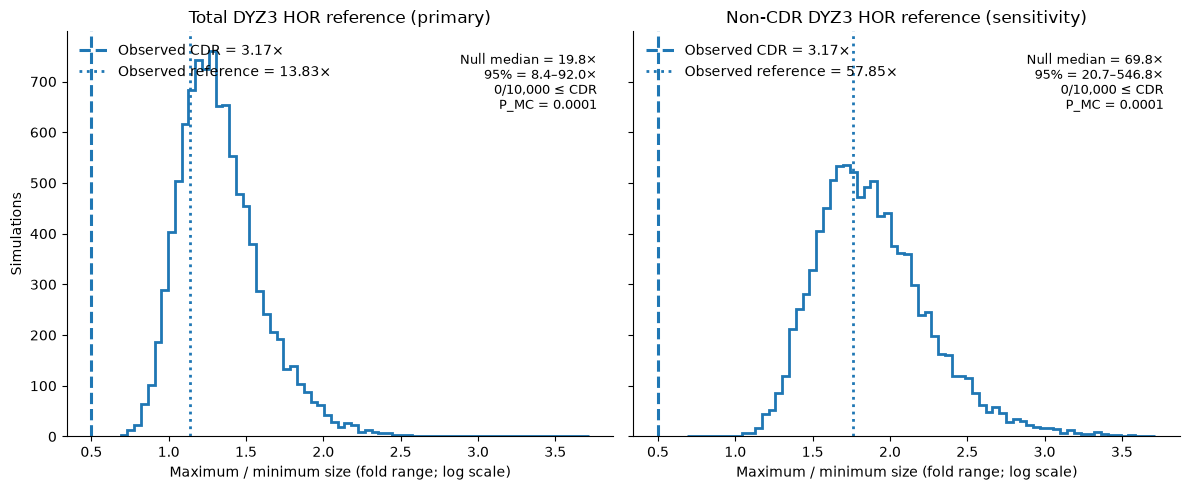

In [17]:
primary_fold = total_hor_null_stats["Fold_range"]
sensitivity_fold = noncdr_null_stats["Fold_range"]
obs_cdr_fold = cdr_obs_stats["Fold_range"]
obs_total_fold = observed_dispersion(centromere_traits["log_HOR"])["Fold_range"]
obs_noncdr_fold = observed_dispersion(centromere_traits["log_non_CDR_HOR"])["Fold_range"]

all_logs = np.concatenate([np.log10(primary_fold), np.log10(sensitivity_fold)])
bins = np.linspace(all_logs.min(), all_logs.max(), 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, title, vals, ref_obs in [
    (axes[0], "Total DYZ3 HOR reference (primary)", primary_fold, obs_total_fold),
    (axes[1], "Non-CDR DYZ3 HOR reference (sensitivity)", sensitivity_fold, obs_noncdr_fold),
]:
    ax.hist(np.log10(vals), bins=bins, histtype="step", linewidth=2)
    ax.axvline(np.log10(obs_cdr_fold), linestyle="--", linewidth=2.2, label=f"Observed CDR = {obs_cdr_fold:.2f}×")
    ax.axvline(np.log10(ref_obs), linestyle=":", linewidth=2.0, label=f"Observed reference = {ref_obs:.2f}×")
    q025, q975 = np.quantile(vals, [0.025, 0.975])
    med = np.median(vals)
    r = int(np.sum(vals <= obs_cdr_fold))
    p = (r + 1) / (len(vals) + 1)
    ax.text(
        0.97, 0.95,
        f"Null median = {med:.1f}×\n95% = {q025:.1f}–{q975:.1f}×\n{r}/{len(vals):,} ≤ CDR\nP_MC = {p:.2g}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
    )
    ax.set_title(title)
    ax.set_xlabel("Maximum / minimum size (fold range; log scale)")
    ax.legend(frameon=False, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Simulations")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure_CDR_range_nulls_side_by_side.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "Figure_CDR_range_nulls_side_by_side.png", dpi=600, bbox_inches="tight")
plt.show()

## 16. Robust-statistic figure for the primary total-HOR reference

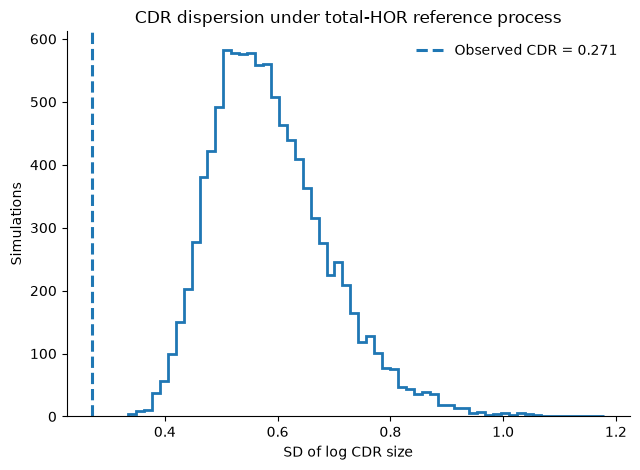

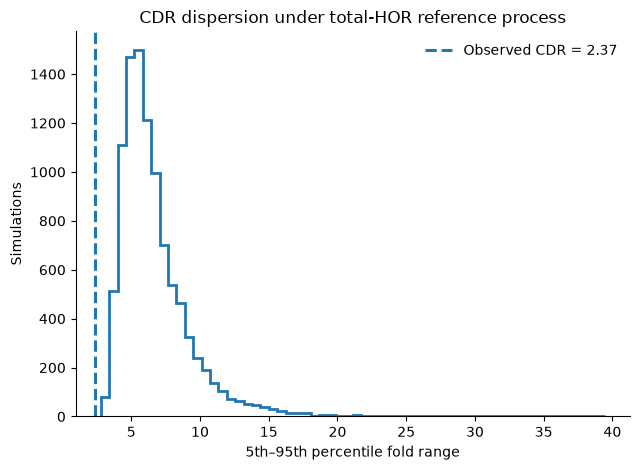

In [18]:
for stat_name, xlabel in [
    ("Log_SD", "SD of log CDR size"),
    ("P05_P95_fold_range", "5th–95th percentile fold range"),
]:
    vals = total_hor_null_stats[stat_name]
    obs = cdr_obs_stats[stat_name]
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.hist(vals, bins=60, histtype="step", linewidth=2)
    ax.axvline(obs, linestyle="--", linewidth=2.2, label=f"Observed CDR = {obs:.3g}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Simulations")
    ax.set_title("CDR dispersion under total-HOR reference process")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    stem = "LogSD" if stat_name == "Log_SD" else "P05_P95_fold_range"
    plt.savefig(OUTPUT_DIR / f"Figure_CDR_primary_null_{stem}.pdf", bbox_inches="tight")
    plt.savefig(OUTPUT_DIR / f"Figure_CDR_primary_null_{stem}.png", dpi=600, bbox_inches="tight")
    plt.show()

## 17. Close-relative / pedigree descriptives

In [19]:
RELATED_GROUPS = {
    "200080_family": ["200080", "200084", "200085"],
    "NA12877_family": ["NA12877", "NA12882", "NA12883", "NA12884", "NA12886"],
    "HG02666_family": ["HG02666", "HG02668"],
}

KNOWN_RELATIONSHIPS = {
    frozenset(["200080", "200084"]): "father-son",
    frozenset(["200080", "200085"]): "father-son",
}

pair_rows = []
group_rows = []
indexed = centromere_model_df.set_index("sample")

for family, members in RELATED_GROUPS.items():
    present = [m for m in members if m in indexed.index]
    missing = [m for m in members if m not in indexed.index]
    if missing:
        print(f"{family}: missing samples {missing}")
    if len(present) < 2:
        continue

    sub = indexed.loc[present]
    group_rows.append({
        "Family_group": family,
        "N_members": len(sub),
        "HOR_min_kb": sub["HOR_kb"].min(),
        "HOR_max_kb": sub["HOR_kb"].max(),
        "HOR_range_kb": sub["HOR_kb"].max() - sub["HOR_kb"].min(),
        "CDR_min_kb": sub["CDR_kb"].min(),
        "CDR_max_kb": sub["CDR_kb"].max(),
        "CDR_range_kb": sub["CDR_kb"].max() - sub["CDR_kb"].min(),
    })

    for a, b in itertools.combinations(present, 2):
        ra, rb = indexed.loc[a], indexed.loc[b]
        pair_rows.append({
            "Family_group": family,
            "Sample_1": a,
            "Sample_2": b,
            "Relationship": KNOWN_RELATIONSHIPS.get(frozenset([a, b]), "within-family pair; role not specified"),
            "HOR_1_kb": ra["HOR_kb"],
            "HOR_2_kb": rb["HOR_kb"],
            "Abs_delta_HOR_kb": abs(ra["HOR_kb"] - rb["HOR_kb"]),
            "CDR_1_kb": ra["CDR_kb"],
            "CDR_2_kb": rb["CDR_kb"],
            "Abs_delta_CDR_kb": abs(ra["CDR_kb"] - rb["CDR_kb"]),
            "Abs_delta_log_HOR": abs(np.log(ra["HOR_kb"]) - np.log(rb["HOR_kb"])),
            "Abs_delta_log_CDR": abs(np.log(ra["CDR_kb"]) - np.log(rb["CDR_kb"])),
        })

related_group_summary = pd.DataFrame(group_rows)
related_pair_table = pd.DataFrame(pair_rows)

display(related_group_summary)
display(related_pair_table)
related_group_summary.to_csv(OUTPUT_DIR / "Supplementary_Table_Related_group_summary.csv", index=False)
related_pair_table.to_csv(OUTPUT_DIR / "Supplementary_Table_Related_pairwise_differences.csv", index=False)

,Family_group,N_members,HOR_min_kb,HOR_max_kb,HOR_range_kb,CDR_min_kb,CDR_max_kb,CDR_range_kb
0,200080_family,3,330.0,330.0,0.0,125,200,75
1,NA12877_family,5,347.0,359.0,12.0,115,200,85
2,HG02666_family,2,897.0,921.0,24.0,175,180,5


,Family_group,Sample_1,Sample_2,Relationship,HOR_1_kb,HOR_2_kb,Abs_delta_HOR_kb,CDR_1_kb,CDR_2_kb,Abs_delta_CDR_kb,Abs_delta_log_HOR,Abs_delta_log_CDR
0,200080_family,200080,200084,father-son,330.0,330.0,0.0,195,200,5,0.000000,0.025318
1,200080_family,200080,200085,father-son,330.0,330.0,0.0,195,125,70,0.000000,0.444686
2,200080_family,200084,200085,within-family pair; role not specified,330.0,330.0,0.0,200,125,75,0.000000,0.470004
3,NA12877_family,NA12877,NA12882,within-family pair; role not specified,359.0,347.0,12.0,200,115,85,0.033998,0.553385
4,NA12877_family,NA12877,NA12883,within-family pair; role not specified,359.0,359.0,0.0,200,150,50,0.000000,0.287682
5,NA12877_family,NA12877,NA12884,within-family pair; role not specified,359.0,359.0,0.0,200,125,75,0.000000,0.470004
6,NA12877_family,NA12877,NA12886,within-family pair; role not specified,359.0,359.0,0.0,200,195,5,0.000000,0.025318
7,NA12877_family,NA12882,NA12883,within-family pair; role not specified,347.0,359.0,12.0,115,150,35,0.033998,0.265703
8,NA12877_family,NA12882,NA12884,within-family pair; role not specified,347.0,359.0,12.0,115,125,10,0.033998,0.083382
9,NA12877_family,NA12882,NA12886,within-family pair; role not specified,347.0,359.0,12.0,115,195,80,0.033998,0.528067


## 19. Summary tables

In [21]:
primary_range = range_null_table.query(
    "Null_model == 'Total DYZ3 HOR (primary)' and Statistic == 'Fold_range'"
).iloc[0]
noncdr_range = range_null_table.query(
    "Null_model == 'Non-CDR DYZ3 HOR (sensitivity)' and Statistic == 'Fold_range'"
).iloc[0]
physical_range = physical_null_table.query("Statistic == 'Fold_range'").iloc[0]
quantized_range = quantized_null_table.query("Statistic == 'Fold_range'").iloc[0]

cdr_lambda = pagel_lambda_table.loc[pagel_lambda_table["Trait"] == "CDR"].iloc[0]
total_lambda = pagel_lambda_table.loc[pagel_lambda_table["Trait"] == "Total DYZ3 HOR"].iloc[0]
noncdr_lambda = pagel_lambda_table.loc[pagel_lambda_table["Trait"] == "Non-CDR DYZ3 HOR"].iloc[0]

headline_table = pd.DataFrame([
    {"Analysis": "Pagel lambda", "Quantity": "CDR lambda", "Estimate": cdr_lambda["Lambda_MLE"], "Lower": cdr_lambda["Lambda_profile_support_low"], "Upper": cdr_lambda["Lambda_profile_support_high"], "P_or_note": "95% profile support interval"},
    {"Analysis": "Pagel lambda", "Quantity": "Total HOR lambda", "Estimate": total_lambda["Lambda_MLE"], "Lower": total_lambda["Lambda_profile_support_low"], "Upper": total_lambda["Lambda_profile_support_high"], "P_or_note": "95% profile support interval"},
    {"Analysis": "Pagel lambda", "Quantity": "Non-CDR HOR lambda", "Estimate": noncdr_lambda["Lambda_MLE"], "Lower": noncdr_lambda["Lambda_profile_support_low"], "Upper": noncdr_lambda["Lambda_profile_support_high"], "P_or_note": "95% profile support interval"},
    {"Analysis": "PGLS", "Quantity": "log CDR ~ log HOR slope", "Estimate": pgls_fit["slope"], "Lower": pgls_fit["slope_CI_low"], "Upper": pgls_fit["slope_CI_high"], "P_or_note": f"P(beta=0)={pgls_fit['P_slope_equals_0']:.3g}; P(beta=1)={pgls_fit['P_slope_equals_1']:.3g}"},
    {"Analysis": "Dispersion effect size", "Quantity": "Total-HOR / CDR log-variance ratio", "Estimate": variance_ratio_hor_to_cdr, "Lower": ci_low, "Upper": ci_high, "P_or_note": f"paired bootstrap n={N_BOOT:,}; descriptive"},
    {"Analysis": "Range null", "Quantity": "Total HOR primary", "Estimate": primary_range["Observed_CDR"], "Lower": primary_range["Null_q025"], "Upper": primary_range["Null_q975"], "P_or_note": f"null median={primary_range['Null_median']:.3g}; P_MC={primary_range['One_sided_Monte_Carlo_P']:.3g}"},
    {"Analysis": "Range null", "Quantity": "Non-CDR HOR sensitivity", "Estimate": noncdr_range["Observed_CDR"], "Lower": noncdr_range["Null_q025"], "Upper": noncdr_range["Null_q975"], "P_or_note": f"null median={noncdr_range['Null_median']:.3g}; P_MC={noncdr_range['One_sided_Monte_Carlo_P']:.3g}"},
    {"Analysis": "Range null", "Quantity": "Physical host-bound sensitivity", "Estimate": physical_range["Observed_CDR"], "Lower": physical_range["Null_q025"], "Upper": physical_range["Null_q975"], "P_or_note": f"null median={physical_range['Null_median']:.3g}; P_MC={physical_range['One_sided_Monte_Carlo_P']:.3g}"},
    {"Analysis": "Range null", "Quantity": "5-kb quantization sensitivity", "Estimate": quantized_range["Observed_CDR"], "Lower": quantized_range["Null_q025"], "Upper": quantized_range["Null_q975"], "P_or_note": f"null median={quantized_range['Null_median']:.3g}; P_MC={quantized_range['One_sided_Monte_Carlo_P']:.3g}"},
])

display(headline_table)
headline_table.to_csv(OUTPUT_DIR / "Supplementary_Table_Centromere_constraint_headline_summary.csv", index=False)

,Analysis,Quantity,Estimate,Lower,Upper,P_or_note
0,Pagel lambda,CDR lambda,0.000000,0.000000,0.115000,95% profile support interval
1,Pagel lambda,Total HOR lambda,1.000000,1.000000,1.000000,95% profile support interval
2,Pagel lambda,Non-CDR HOR lambda,0.986169,0.965000,0.994000,95% profile support interval
3,PGLS,log CDR ~ log HOR slope,0.064298,-0.024203,0.152799,P(beta=0)=0.153; P(beta=1)=4.96e-42
4,Dispersion effect size,Total-HOR / CDR log-variance ratio,4.066135,3.006743,5.487242,"paired bootstrap n=20,000; descriptive"
5,Range null,Total HOR primary,3.166667,8.354454,91.965209,null median=19.8; P_MC=0.0001
6,Range null,Non-CDR HOR sensitivity,3.166667,20.697069,546.831510,null median=69.8; P_MC=0.0001
7,Range null,Physical host-bound sensitivity,3.166667,8.148773,64.857500,null median=18.1; P_MC=0.0005
8,Range null,5-kb quantization sensitivity,3.166667,8.250000,92.256250,null median=20; P_MC=0.0001
